# EDA with Python and applying Logistic Regression

for this lecture we will be working with the Titanic Data Set From Kaggle. This is a very famous data set and very often is a students first step in machine


We will be trying to predict a classification survival deceased. Lets begin our understandingg of implementing Logistic Regression in Python for Classification.

We will use a "semi-cleaned" version of the titanic dataset. if you use the dataset hosted directly on kaggle, you may need to do some additional cleaning not shown in this lecture notebook

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

**The data**

Lets start by reading in the titanic_train.csv file into a pandas dataframe

In [27]:
import kagglehub
path = kagglehub.dataset_download("yasserh/titanic-dataset")

In [28]:
import os
train=pd.read_csv(os.path.join(path, 'Titanic-Dataset.csv'))

In [29]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Exploratory Data Analysis**

Let's begin some exploratory data analysis! We'll start by checking out missing data!

**Missing Data**

We can use seaborn to create a simple heatmap to see where we are missing data!

In [30]:
train.isnull()
#train.isnull() shows you exactly where your dataset has missing values. It returns True for every missing piece of data and False otherwise.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

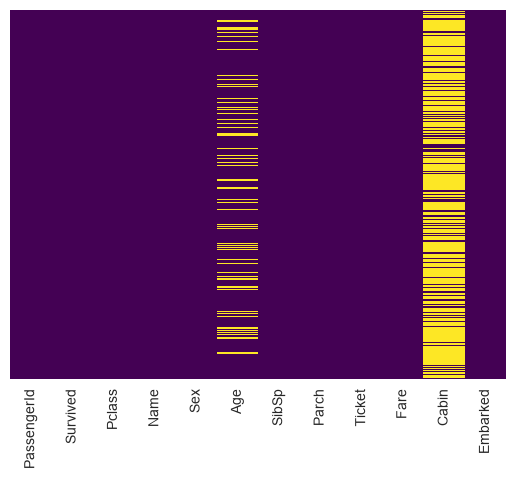

In [31]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

<Axes: xlabel='Survived', ylabel='count'>

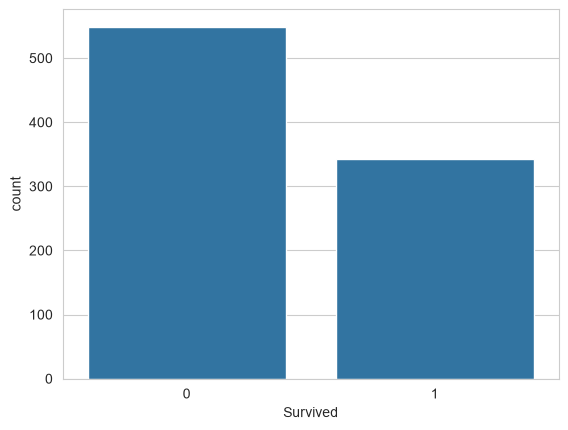

In [32]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', data=train)

<Axes: xlabel='Survived', ylabel='count'>

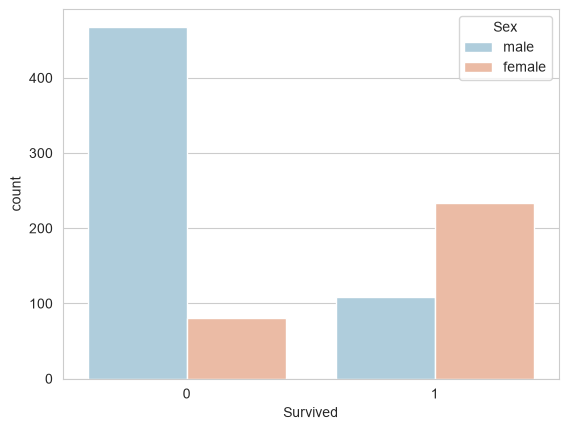

In [33]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Sex', data=train, palette='RdBu_r')
#In the countplot we just used, hue='Sex' meant that the bars for 'Survived' (0 or 1) were further split and colored based on whether the passenger was 'male' or 'female'. This allowed us to see not just the total count of survivors and non-survivors, but also how those counts were distributed between males and females.

In the countplot we just used, hue='Sex' meant that the bars for 'Survived' (0 or 1) were further split and colored based on whether the passenger was 'male' or 'female'. This allowed us to see not just the total count of survivors and non-survivors, but also how those counts were distributed between males and females.

<Axes: xlabel='Survived', ylabel='count'>

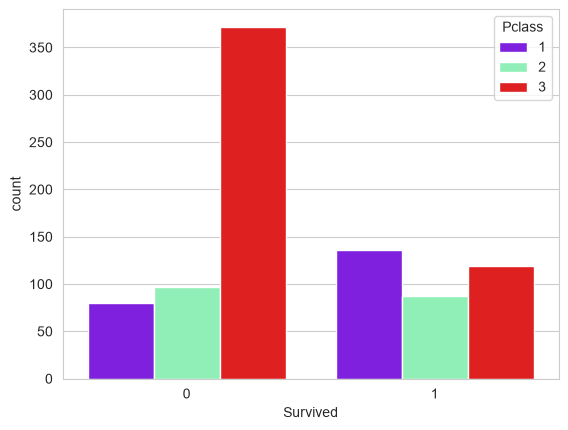

In [34]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Pclass', data=train, palette='rainbow')

C:\Users\rajsh\AppData\Local\Temp\ipykernel_9868\1259507556.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Age'].dropna(),kde=False, color='darkred', bins=40)


<Axes: xlabel='Age'>

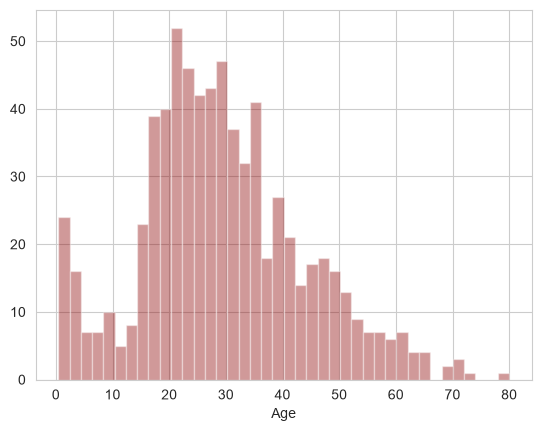

In [35]:
#distributon of the age
sns.distplot(train['Age'].dropna(),kde=False, color='darkred', bins=40)

#kde stands for kernel density distribution, it is set to false ie user dont want to show this

The bins parameter in a histogram (which sns.distplot creates when kde=False) determines how the data is divided into intervals, or "bins." Each bin represents a range of values, and the height of the bar for that bin indicates the number of data points (or frequency) that fall within that range.

<Axes: >

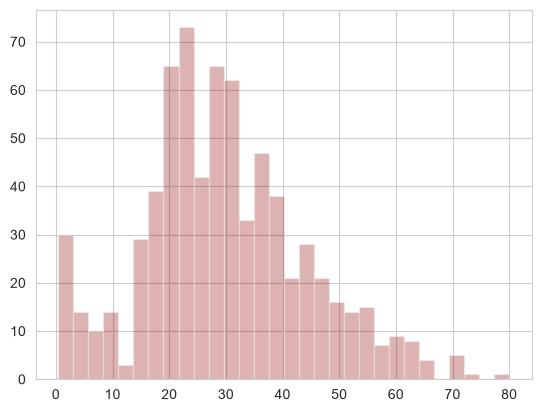

In [36]:
train['Age'].hist(bins=30, color='darkred', alpha=0.3)

<Axes: xlabel='SibSp', ylabel='count'>

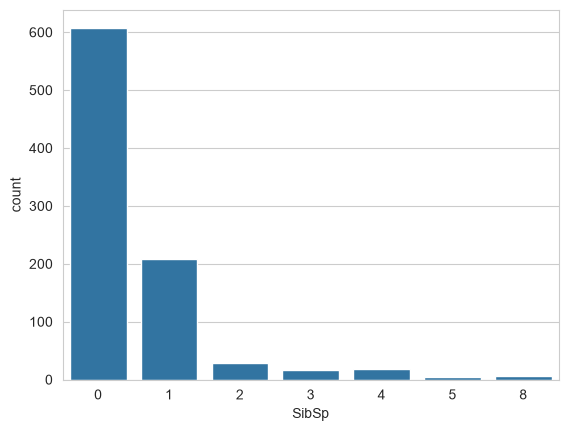

In [37]:
sns.countplot(x='SibSp', data=train)

<Axes: >

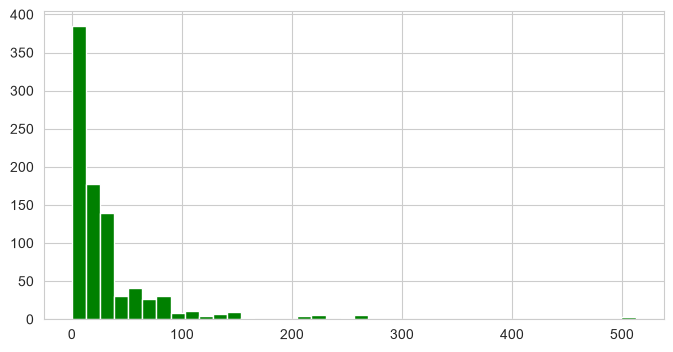

In [38]:
train['Fare'].hist(color='green', bins=40, figsize=(8,4))

# Data Cleaning

we want to fill in missing age data instead of just dropping the missing age data rows. One way to do this by filling in the mean age of the passengers (imputation). However we can be smarter about this and check the average age by passengers class

C:\Users\rajsh\AppData\Local\Temp\ipykernel_9868\1152948113.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age', data=train, palette='winter')


<Axes: xlabel='Pclass', ylabel='Age'>

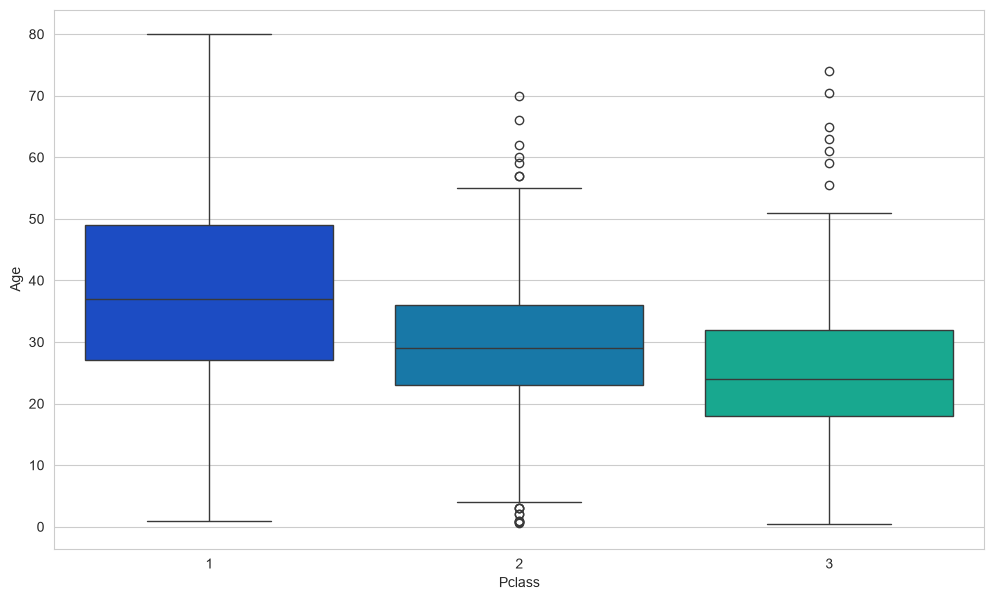

In [39]:
plt.figure(figsize=(12,7))
sns.boxplot(x='Pclass', y='Age', data=train, palette='winter')

In [43]:
#we can see the wealthier passengers in the higher classes tend to be older which makes sense. we will use these avg age values to impute based on Pclass for Age

def impute_age(cols):
  Age=cols[0]
  Pclass=cols[1]

  if pd.isnull(Age):
    if Pclass == 1:
      return 37
    elif Pclass==2:
      return 29
    else:
      return 24
  else:
    return Age

Now aaply that function

In [44]:
train['Age']=train[['Age','Pclass']].apply(impute_age, axis=1)

KeyError: 0

In [45]:
train.dropna(inplace=True)

Now lets check the heatmap again

In [ ]:
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')

Great! Lets go ahead and drop the cabn column and the row in EMbarked that is NaN

In [47]:
train.drop('Cabin', axis=1, inplace=True)

In [46]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S


In [48]:
train.dropna(inplace=True)

# Converting Categorical Features

We wil need to convert categorical features to dummy variables using pandas. Otherwise our machine learnng algo wont be able to directly take in those features as input

In [49]:
train.info()

<class 'pandas.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  183 non-null    int64  
 1   Survived     183 non-null    int64  
 2   Pclass       183 non-null    int64  
 3   Name         183 non-null    str    
 4   Sex          183 non-null    str    
 5   Age          183 non-null    float64
 6   SibSp        183 non-null    int64  
 7   Parch        183 non-null    int64  
 8   Ticket       183 non-null    str    
 9   Fare         183 non-null    float64
 10  Embarked     183 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 17.2 KB


In [50]:
pd.get_dummies(train['Embarked'], drop_first=True).head()

,Q,S
1,False,False
3,False,True
6,False,True
10,False,True
11,False,True


In [51]:
sex=pd.get_dummies(train['Sex'], drop_first=True)
embark=pd.get_dummies(train['Embarked'], drop_first=True)

In [52]:
train.drop(['Sex', 'Embarked', 'Name', 'Ticket'], axis=1, inplace=True)

In [53]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
1,2,1,1,38.0,1,0,71.2833
3,4,1,1,35.0,1,0,53.1000
6,7,0,1,54.0,0,0,51.8625
10,11,1,3,4.0,1,1,16.7000
11,12,1,1,58.0,0,0,26.5500


In [54]:
train=pd.concat([train, sex,embark], axis=1)

In [55]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
1,2,1,1,38.0,1,0,71.2833,False,False,False
3,4,1,1,35.0,1,0,53.1000,False,False,True
6,7,0,1,54.0,0,0,51.8625,True,False,True
10,11,1,3,4.0,1,1,16.7000,False,False,True
11,12,1,1,58.0,0,0,26.5500,False,False,True


# Building a Logistic Regression Model

Lets start by splitting our data into a training set and test set

**Train Test Split**

In [56]:
train.drop('Survived', axis=1).head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,male,Q,S
1,2,1,38.0,1,0,71.2833,False,False,False
3,4,1,35.0,1,0,53.1000,False,False,True
6,7,1,54.0,0,0,51.8625,True,False,True
10,11,3,4.0,1,1,16.7000,False,False,True
11,12,1,58.0,0,0,26.5500,False,False,True


In [57]:
train['Survived'].head()

1     1
3     1
6     0
10    1
11    1
Name: Survived, dtype: int64

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
X_train, X_test, y_train, y_test= train_test_split(train.drop('Survived', axis=1), 
                                                    train['Survived'], test_size=0.30,
                                                    random_state=101)

# Training and Predicting

In [60]:
from sklearn.linear_model import LogisticRegression

In [65]:
logmodel = LogisticRegression()
logmodel.fit(X_train, y_train)

C:\Users\rajsh\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [62]:
from sklearn.metrics import confusion_matrix

In [67]:
predictions = logmodel.predict(X_test)
accuracy = confusion_matrix(y_test, predictions)

In [68]:
accuracy

array([[10, 12],
       [ 5, 28]])

In [69]:
from sklearn.metrics import accuracy_score


In [70]:
accuracy=accuracy_score(y_test, predictions)
accuracy

0.6909090909090909

In [71]:
predictions

array([1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0])